## EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from urllib.parse import urlparse


file_path = r"dataset_detik_sport_finance.xlsx"

df = pd.read_excel(file_path)

print("=" * 70)
print("INFORMASI DATASET")
print("=" * 70)

print("Jumlah baris   :", df.shape[0])
print("Jumlah kolom   :", df.shape[1])

print("\nNama kolom:")
print(df.columns.tolist())

print("\n5 data pertama:")
print(df.head())

INFORMASI DATASET
Jumlah baris   : 200
Jumlah kolom   : 4

Nama kolom:
['id', 'isi_berita', 'label', 'link_berita']

5 data pertama:
   id                                         isi_berita  label  \
0   1  Pegokar muda Indonesia, Morgan Holindo, tak pu...  sport   
1   2  Pacuan kuda Indonesia mulai diarahkan menuju p...  sport   
2   3  Jelang Asian Games 2026, dukungan untuk 432 at...  sport   
3   4  Pupus sudah harapan Sean Gelael dan rekan-reka...  sport   
4   5  Barra Ghaisan Zeinatma menunjukkan perkembanga...  sport   

                                         link_berita  
0  https://sport.detik.com/sport-lain/d-8654641/a...  
1  https://sport.detik.com/sport-lain/d-8654586/i...  
2  https://sport.detik.com/sport-lain/d-8654342/m...  
3  https://sport.detik.com/sport-lain/d-8653123/w...  
4  https://sport.detik.com/sport-lain/d-8653014/d...  


In [3]:
# INFORMASI TIPE DATA

print("\n" + "=" * 70)
print("TIPE DATA")
print("=" * 70)

print(df.info())


TIPE DATA
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           200 non-null    int64
 1   isi_berita   200 non-null    str  
 2   label        200 non-null    str  
 3   link_berita  200 non-null    str  
dtypes: int64(1), str(3)
memory usage: 6.4 KB
None


In [4]:
# CEK MISSING VALUE

print("\n" + "=" * 70)
print("MISSING VALUE")
print("=" * 70)

missing = df.isnull().sum()

print(missing)

print("\nPersentase missing value:")
print((df.isnull().sum() / len(df) * 100).round(2))


MISSING VALUE
id             0
isi_berita     0
label          0
link_berita    0
dtype: int64

Persentase missing value:
id             0.0
isi_berita     0.0
label          0.0
link_berita    0.0
dtype: float64


In [5]:
# CEK DATA DUPLIKAT

print("\n" + "=" * 70)
print("DUPLIKASI DATA")
print("=" * 70)

print("Jumlah baris duplikat :", df.duplicated().sum())

print("\nDuplikasi berdasarkan isi berita:")
print(df["isi_berita"].duplicated().sum())

print("\nDuplikasi berdasarkan link:")
print(df["link_berita"].duplicated().sum())


DUPLIKASI DATA
Jumlah baris duplikat : 0

Duplikasi berdasarkan isi berita:
0

Duplikasi berdasarkan link:
0



DISTRIBUSI LABEL
label
sport      100
finance    100
Name: count, dtype: int64

Persentase setiap label:
label
sport      50.0
finance    50.0
Name: proportion, dtype: float64


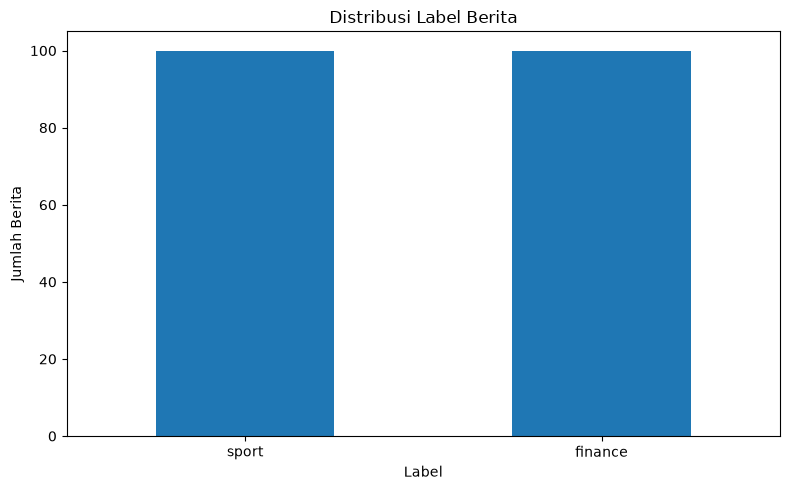

In [6]:
# DISTRIBUSI LABEL

print("\n" + "=" * 70)
print("DISTRIBUSI LABEL")
print("=" * 70)

label_count = df["label"].value_counts()

print(label_count)

print("\nPersentase setiap label:")
print((df["label"].value_counts(normalize=True) * 100).round(2))

# Visualisasi distribusi label
plt.figure(figsize=(8, 5))

label_count.plot(kind="bar")

plt.title("Distribusi Label Berita")
plt.xlabel("Label")
plt.ylabel("Jumlah Berita")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# MENGHITUNG JUMLAH KATA

df["jumlah_kata"] = df["isi_berita"].fillna("").apply(
    lambda x: len(str(x).split())
)

print("\n" + "=" * 70)
print("STATISTIK JUMLAH KATA")
print("=" * 70)

print(df["jumlah_kata"].describe())


STATISTIK JUMLAH KATA
count     200.000000
mean      352.025000
std       153.264492
min       130.000000
25%       253.000000
50%       316.500000
75%       400.000000
max      1085.000000
Name: jumlah_kata, dtype: float64


In [8]:
# MENGHITUNG JUMLAH KARAKTER

df["jumlah_karakter"] = df["isi_berita"].fillna("").apply(
    lambda x: len(str(x))
)

print("\n" + "=" * 70)
print("STATISTIK JUMLAH KARAKTER")
print("=" * 70)

print(df["jumlah_karakter"].describe())


STATISTIK JUMLAH KARAKTER
count     200.000000
mean     2573.715000
std      1168.638831
min      1025.000000
25%      1773.500000
50%      2335.000000
75%      3003.750000
max      8525.000000
Name: jumlah_karakter, dtype: float64


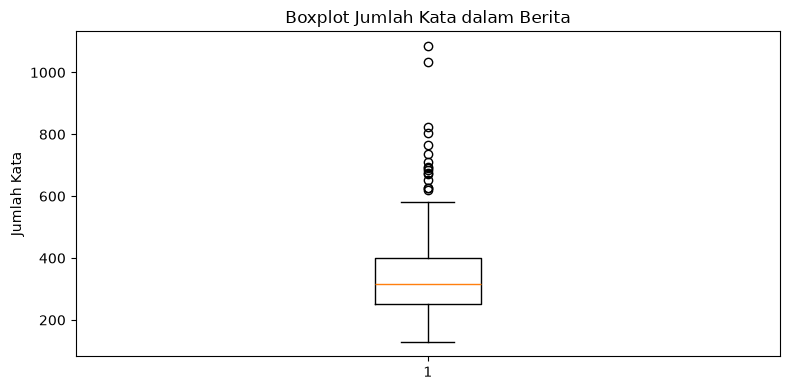

In [10]:
# BOX PLOT JUMLAH KATA

plt.figure(figsize=(8, 4))

plt.boxplot(df["jumlah_kata"])

plt.title("Boxplot Jumlah Kata dalam Berita")
plt.ylabel("Jumlah Kata")
plt.tight_layout()
plt.show()

In [11]:
# STATISTIK JUMLAH KATA BERDASARKAN LABEL

print("\n" + "=" * 70)
print("JUMLAH KATA BERDASARKAN LABEL")
print("=" * 70)

statistik_label = df.groupby("label")["jumlah_kata"].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

print(statistik_label.round(2))


JUMLAH KATA BERDASARKAN LABEL
         count    mean  median  min   max     std
label                                            
finance    100  349.35   321.0  130  1085  154.98
sport      100  354.70   314.5  145   822  152.26


In [12]:
# BERITA TERPENDEK DAN TERPANJANG

print("\n" + "=" * 70)
print("BERITA TERPENDEK")
print("=" * 70)

berita_terpendek = df.loc[
    df["jumlah_kata"].idxmin(),
    ["id", "label", "jumlah_kata", "link_berita"]
]

print(berita_terpendek)


print("\n" + "=" * 70)
print("BERITA TERPANJANG")
print("=" * 70)

berita_terpanjang = df.loc[
    df["jumlah_kata"].idxmax(),
    ["id", "label", "jumlah_kata", "link_berita"]
]

print(berita_terpanjang)



BERITA TERPENDEK
id                                                           149
label                                                    finance
jumlah_kata                                                  130
link_berita    https://finance.detik.com/berita-ekonomi-bisni...
Name: 148, dtype: object

BERITA TERPANJANG
id                                                           193
label                                                    finance
jumlah_kata                                                 1085
link_berita    https://finance.detik.com/berita-ekonomi-bisni...
Name: 192, dtype: object


In [13]:
# OUTLIER PANJANG BERITA

Q1 = df["jumlah_kata"].quantile(0.25)
Q3 = df["jumlah_kata"].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier = df[
    (df["jumlah_kata"] < batas_bawah) |
    (df["jumlah_kata"] > batas_atas)
]

print("\n" + "=" * 70)
print("OUTLIER PANJANG BERITA")
print("=" * 70)

print("Q1          :", Q1)
print("Q3          :", Q3)
print("IQR         :", IQR)
print("Batas bawah :", batas_bawah)
print("Batas atas  :", batas_atas)
print("Jumlah outlier :", len(outlier))



OUTLIER PANJANG BERITA
Q1          : 253.0
Q3          : 400.0
IQR         : 147.0
Batas bawah : 32.5
Batas atas  : 620.5
Jumlah outlier : 16


## Preprocessing

### Case Folding

In [16]:
df["teks_lower"] = df["isi_berita"].str.lower()

df[["isi_berita", "teks_lower"]].head()

,isi_berita,teks_lower
0,"Pegokar muda Indonesia, Morgan Holindo, tak pu...","pegokar muda indonesia, morgan holindo, tak pu..."
1,Pacuan kuda Indonesia mulai diarahkan menuju p...,pacuan kuda indonesia mulai diarahkan menuju p...
2,"Jelang Asian Games 2026, dukungan untuk 432 at...","jelang asian games 2026, dukungan untuk 432 at..."
3,Pupus sudah harapan Sean Gelael dan rekan-reka...,pupus sudah harapan sean gelael dan rekan-reka...
4,Barra Ghaisan Zeinatma menunjukkan perkembanga...,barra ghaisan zeinatma menunjukkan perkembanga...


## Cleaning

In [27]:
import string

def cleaning(text):
    text = str(text)

    text = re.sub(
        r'\([a-z]{2,5}/[a-z]{2,5}\)',
        ' ',
        text,
        flags=re.IGNORECASE
    )
    
    # Hapus angka
    text = re.sub(r"\d+", " ", text)
    
    # Hapus tanda baca
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Hapus karakter selain huruf dan spasi
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Hapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["teks_clean"] = df["teks_lower"].apply(cleaning)

df[["teks_lower", "teks_clean"]].head()

,teks_lower,teks_clean
0,"pegokar muda indonesia, morgan holindo, tak pu...",pegokar muda indonesia morgan holindo tak puas...
1,pacuan kuda indonesia mulai diarahkan menuju p...,pacuan kuda indonesia mulai diarahkan menuju p...
2,"jelang asian games 2026, dukungan untuk 432 at...",jelang asian games dukungan untuk atlet indone...
3,pupus sudah harapan sean gelael dan rekan-reka...,pupus sudah harapan sean gelael dan rekanrekan...
4,barra ghaisan zeinatma menunjukkan perkembanga...,barra ghaisan zeinatma menunjukkan perkembanga...


## Tokenisasi

In [28]:
df["tokens"] = df["teks_clean"].apply(lambda x: x.split())

df[["teks_clean", "tokens"]].head()

,teks_clean,tokens
0,pegokar muda indonesia morgan holindo tak puas...,"[pegokar, muda, indonesia, morgan, holindo, ta..."
1,pacuan kuda indonesia mulai diarahkan menuju p...,"[pacuan, kuda, indonesia, mulai, diarahkan, me..."
2,jelang asian games dukungan untuk atlet indone...,"[jelang, asian, games, dukungan, untuk, atlet,..."
3,pupus sudah harapan sean gelael dan rekanrekan...,"[pupus, sudah, harapan, sean, gelael, dan, rek..."
4,barra ghaisan zeinatma menunjukkan perkembanga...,"[barra, ghaisan, zeinatma, menunjukkan, perkem..."


In [29]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

df["tokens_no_stopword"] = df["tokens"].apply(remove_stopwords)

df[["tokens", "tokens_no_stopword"]].head()

,tokens,tokens_no_stopword
0,"[pegokar, muda, indonesia, morgan, holindo, ta...","[pegokar, muda, indonesia, morgan, holindo, ta..."
1,"[pacuan, kuda, indonesia, mulai, diarahkan, me...","[pacuan, kuda, indonesia, mulai, diarahkan, me..."
2,"[jelang, asian, games, dukungan, untuk, atlet,...","[jelang, asian, games, dukungan, atlet, indone..."
3,"[pupus, sudah, harapan, sean, gelael, dan, rek...","[pupus, harapan, sean, gelael, rekanrekannya, ..."
4,"[barra, ghaisan, zeinatma, menunjukkan, perkem...","[barra, ghaisan, zeinatma, menunjukkan, perkem..."


## Stemming

In [30]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df["tokens_stem"] = df["tokens_no_stopword"].apply(stemming)

df[["tokens_no_stopword", "tokens_stem"]].head()

df["teks_preprocessed"] = df["tokens_stem"].apply(
    lambda x: " ".join(x)
)

df[["isi_berita", "teks_preprocessed", "label"]]

,isi_berita,teks_preprocessed,label
0,"Pegokar muda Indonesia, Morgan Holindo, tak pu...",gokar muda indonesia morgan holindo tak puas c...,sport
1,Pacuan kuda Indonesia mulai diarahkan menuju p...,pacu kuda indonesia mulai arah tuju panggung d...,sport
2,"Jelang Asian Games 2026, dukungan untuk 432 at...",jelang asi games dukung atlet indonesia terus ...,sport
3,Pupus sudah harapan Sean Gelael dan rekan-reka...,pupus harap sean gelael rekanrekannya team wrt...,sport
4,Barra Ghaisan Zeinatma menunjukkan perkembanga...,barra ghaisan zeinatma tunjuk kembang positif ...,sport
...,...,...,...
195,Penutupan beberapa bandara imbas abu vulkanik ...,tutup beberapa bandara imbas abu vulkanik gunu...,finance
196,Layanan angkutan penyeberangan lintas Merak-Ba...,layan angkut seberang lintas merakbakauheni te...,finance
197,Menteri Perhubungan Dudy Purwagandhi menyampai...,menteri hubung dudy purwagandhi sampai dapat d...,finance
198,Menteri Perhubungan Dudy Purwagandhi menyataka...,menteri hubung dudy purwagandhi nyata tutup de...,finance


In [35]:
df.to_csv("dataset_preprocessed.csv", index=False)

## Mencari Kata Unik

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

# Ambil hanya kolom teks_preprocessed
berita = df["teks_preprocessed"].fillna("").astype(str)

# Membuat CountVectorizer
vectorizer = CountVectorizer()

# Fit pada isi berita
vectorizer.fit(berita)

# Mendapatkan kata-kata unik
kata_unik = vectorizer.get_feature_names_out()

# Menampilkan jumlah kata unik
print("Jumlah kata unik:", len(kata_unik))

# Menampilkan semua kata unik
print(kata_unik)

df_kata_unik = pd.DataFrame({
    "kata_unik": kata_unik
})

# Simpan ke Excel
df_kata_unik.to_csv("kata_unik.csv", index=False)

print("Kata unik berhasil disimpan ke: kata_unik.csv")

Jumlah kata unik: 5280
['aa' 'aaron' 'aaustralia' ... 'zuhair' 'zulhas' 'zulkifli']
Kata unik berhasil disimpan ke: kata_unik.csv


## Representasi TF-IDF

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


berita = pd.read_excel("dataset_detik_sport_finance.xlsx")
berita = berita.head(200).copy()

berita["isi_berita"] = berita["isi_berita"].fillna("")

kata_unik = pd.read_csv("kata_unik.csv")
vocabulary = kata_unik["kata_unik"].dropna().astype(str).tolist()

print("Jumlah kata unik:", len(vocabulary))

# Membuat TF-IDF
vectorizer = TfidfVectorizer(
    vocabulary=vocabulary,
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b"
)

tfidf_matrix = vectorizer.fit_transform(berita["isi_berita"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

hasil = pd.concat(
    [
        berita[["id"]].reset_index(drop=True),
        tfidf_df,
        berita[["label"]].reset_index(drop=True)
    ],
    axis=1
)

hasil.to_excel(
    "representasi_tfidf_berita.xlsx",
    index=False
)

print("Representasi TF-IDF berhasil dibuat!")
print("Ukuran data:", hasil.shape)
print("File: representasi_tfidf_berita.xlsx")

Jumlah kata unik: 5280
Representasi TF-IDF berhasil dibuat!
Ukuran data: (200, 5282)
File: representasi_tfidf_berita.xlsx


In [4]:
print(hasil.head(5))

   id   aa  aaron  aaustralia   ab  abai  abdi  abdu  abdul  abdullah  ...  \
0   1  0.0    0.0         0.0  0.0   0.0   0.0   0.0    0.0       0.0  ...   
1   2  0.0    0.0         0.0  0.0   0.0   0.0   0.0    0.0       0.0  ...   
2   3  0.0    0.0         0.0  0.0   0.0   0.0   0.0    0.0       0.0  ...   
3   4  0.0    0.0         0.0  0.0   0.0   0.0   0.0    0.0       0.0  ...   
4   5  0.0    0.0         0.0  0.0   0.0   0.0   0.0    0.0       0.0  ...   

   zetterwall  zharfan  zigmars  zona  zone  zoom  zuhair  zulhas  zulkifli  \
0         0.0      0.0      0.0   0.0   0.0   0.0     0.0     0.0       0.0   
1         0.0      0.0      0.0   0.0   0.0   0.0     0.0     0.0       0.0   
2         0.0      0.0      0.0   0.0   0.0   0.0     0.0     0.0       0.0   
3         0.0      0.0      0.0   0.0   0.0   0.0     0.0     0.0       0.0   
4         0.0      0.0      0.0   0.0   0.0   0.0     0.0     0.0       0.0   

   label  
0  sport  
1  sport  
2  sport  
3  sport  
4

## Reduksi Dimensi Data TF-IDF Menggunakan PCA

In [5]:
from sklearn.decomposition import PCA

X_tfidf = hasil.iloc[:, 1:-1]
y = hasil["label"]

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_tfidf)

pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

hasil_pca = pd.concat(
    [
        hasil[["id"]].reset_index(drop=True),
        pca_df,
        y.reset_index(drop=True)
    ],
    axis=1
)

print("Dimensi sebelum PCA:", X_tfidf.shape)
print("Dimensi setelah PCA:", X_pca.shape)

print("\nJumlah komponen PCA:", pca.n_components_)
print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

print("\nHasil PCA:")
print(hasil_pca.head(10))

hasil_pca.to_excel(
    "hasil_pca_berita.xlsx",
    index=False
)

Dimensi sebelum PCA: (200, 5280)
Dimensi setelah PCA: (200, 157)

Jumlah komponen PCA: 157
Total explained variance: 0.9505769655433083

Hasil PCA:
   id       PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0   1 -0.172961 -0.156374  0.258901 -0.070385 -0.016816  0.133199 -0.195487   
1   2 -0.108650  0.151115  0.002210 -0.041192 -0.260383 -0.011584  0.140552   
2   3 -0.167435  0.400699 -0.003083  0.007391  0.032096  0.006234  0.021439   
3   4 -0.102981 -0.165467  0.234194 -0.023988  0.007609  0.132624 -0.238357   
4   5 -0.128036 -0.083972  0.250605 -0.013406 -0.048957  0.102530 -0.211503   
5   6 -0.053268 -0.139105  0.245556 -0.023478 -0.020214  0.099922 -0.195722   
6   7 -0.084596 -0.119882  0.265705 -0.046283 -0.033082  0.091344 -0.220388   
7   8 -0.082840  0.150037 -0.050959 -0.073338 -0.043341 -0.003074  0.088011   
8   9 -0.065968 -0.093055  0.090434 -0.040589  0.089311 -0.041608  0.060806   
9  10 -0.120070 -0.146380  0.278368 -0.017227 -0.018516  0.076